Harini
814724243051
Exp2-character recognition using CNN
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.9196 - loss: 0.2640 - val_accuracy: 0.9848 - val_loss: 0.0549
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9727 - loss: 0.0923 - val_accuracy: 0.9878 - val_loss: 0.0434
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.9807 - loss: 0.0673 - val_accuracy: 0.9885 - val_loss: 0.0410
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9839 - loss: 0.0551 - val_accuracy: 0.9903 - val_loss: 0.0349
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9857 - loss: 0.0475 - val_accuracy: 0.9905 - val_loss: 0.0376
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9891 - loss: 0.0321

Test Accuracy: 0.9890999794006348
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


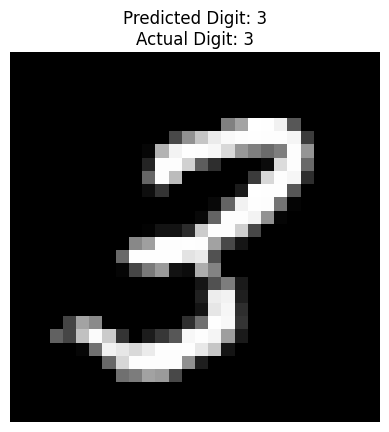

In [ ]:
print("Harini")
print("814724243051")
print("Exp2-character recognition using CNN")
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape data for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

# Evaluate model
loss, accuracy = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", accuracy)

# Predict one test image
index = np.random.randint(0, len(x_test))

prediction = model.predict(x_test[index].reshape(1,28,28,1))
predicted_digit = np.argmax(prediction)

# Display image
plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}\nActual Digit: {y_test[index]}")
plt.axis("off")
plt.show()